# Surface flux response to the net radiative forcing, DLR + SW$_{net}$ — NSA C1 observations

Companion to `seb_flux_response_to_DLR.ipynb`, and the observational twin of
`ERA5/surface_energy_budget/turbulent_flux_response_to_DLR_and_SW.ipynb`. The
forcer is now $F = LWD + SW_{net}$, the one Sledd et al. (2025) use (their
Sect. 3.2, Eq. 9), so every number here is directly comparable with their
Figs. 1–3.

**Why the second forcer.** In polar night a thinner cloud changes DLR and nothing
else, and the two forcers coincide. In October and March a thinner cloud also
lets more shortwave through: regressing on DLR alone then books the shortwave
part of the response as a *responder* ($f_{SW}$) when it is really part of the
*forcing*. With $F = LWD + SW_{net}$ the partition has four terms,

$$1 = \underbrace{\frac{d(LWU)}{dF}}_{f_{LWU}}
    + \underbrace{\frac{d(SH_{up})}{dF}}_{f_{SH}}
    + \underbrace{\frac{d(LH_{up})}{dF}}_{f_{LH}}
    + \underbrace{\frac{d(NA)}{dF}}_{f_{res}},
\qquad NA = F - LWU - SH - LH = M - SWT - G,$$

and Sledd's closure statement (their Eq. 9) is that the *measured* responders
$LWU + SH + LH - G$ (with $M = SWT = 0$ in winter) respond to $F$ with a total
slope of one. At MOSAiC the winter total was 0.94–1.08.

## Contents

| section | content |
|---|---|
| variables | the Sledd terms, what Barrow supplies, and why closure means less here |
| 1 | sign conventions, and the identity checked numerically |
| 2 | December: the Sledd Fig. 1 panels, with their December 2019 slopes |
| 3 | the four responders (and $-G$) against $F$, by population |
| 4 | the partition on the two forcers side by side, with bootstrap intervals |
| 5 | month by month against MOSAiC (Sledd Fig. 2a) and the ERA5 cell |
| 6 | closure: $dNA/dF$ against $d(-G_{TI})/dF$, and the "total measured response" |
| 7 | Sledd's winter window, and their Fig. 3a observational range |
| 8 | the control ladder and the bulk-flux free parameters |
| 9 | 10-min against hourly |


## Setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd() if (Path.cwd() / "arm_nsa").is_dir() else Path.cwd().parent
sys.path.insert(0, str(REPO))
from arm_nsa import flux_response as fr

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100          # on-screen; saved PNGs use fr.FIG_DPI

SEASON = "2025-10-01_2026-03-31"
PRODUCTS = REPO / "data" / "processed"
SAVE_DIR = REPO / "figures" / "seb_flux_response"   # None to only display
N_BOOT = 1000                                        # bootstrap draws (2000 in the ERA5 notebooks)


## Load

In [2]:
# The 10-min product is the Sledd et al. (2025) cadence (their observations are
# 10-min means); the hourly product is the ERA5 cadence. Both were built by
# scripts/build_nsa_seb_hourly.py from the same 1-min streams.
OBS = fr.load_product(PRODUCTS / f"nsa_seb_10min_{SEASON}.nc")
OBS_H = fr.load_product(PRODUCTS / f"nsa_seb_hourly_{SEASON}.nc")
MASKS = fr.population_masks(OBS)
MASKS_H = fr.population_masks(OBS_H)

# ERA5 at the grid cell nearest NSA C1 (71.25 N, 156.5 W; a coastal cell, ERA5
# land fraction 0.62), on the same Eq. (1) terms via the ERA5 seb_terms module.
ERA5 = fr.load_era5_cell("2025-10-01", "2026-03-31")
ERA5_MASKS = fr.population_masks(ERA5) if ERA5 is not None else None

print(f"10-min samples: {OBS.sizes['time']:,}   hourly: {OBS_H.sizes['time']:,}   "
      f"ERA5 hours: {ERA5.sizes['time'] if ERA5 is not None else 'n/a'}")
print("populations (10-min):", {k: int(v.sum()) for k, v in MASKS.items()})
print()
print(fr.variable_check_table(OBS))


10-min samples: 26,160   hourly: 4,362   ERA5 hours: 4368
populations (10-min): {'all': 26160, 'cloudy': 17366, 'liquid': 11017, 'clear': 6258}



term             valid   how it is obtained at NSA C1
LWD             100.0%   measured (SKYRAD pyrgeometers, QCRAD QC; two-pyrgeometer best estimate)
LWU             100.0%   measured (GNDRAD pyrgeometer at 10 m)
SWD, SWU         99.8%   measured (QCRAD); SWN = SWD - SWU
T_skin          100.0%   IRT brightness T corrected for emissivity 0.985 + reflected LWD; LWU inversion as fallback (Sledd: LWU inversion)
SH               99.6%   BULK PARAMETERIZATION (MOST; Sledd: eddy covariance)
LH               99.6%   BULK PARAMETERIZATION (Sledd: eddy covariance)
G               100.0%   ESTIMATED from T_skin history (thermal inertia); also as Eq. (5) residual (Sledd: IMB conduction + storage in a 6-cm slab)
SWT               --     zero: snow deeper than the 6-cm slab over opaque tundra (Sledd: Beer's law, Eq. 6)
M                 --     zero, frozen surface Oct-Mar (Sledd: residual, ~0 in winter)
NA               99.4%   LWD - LWU + SWN - SH - LH (Eq. 5)
T_2m, U_10m     100.0%   measured (ME

## Do we have the right variables? Sledd et al. (2025) term by term

Sledd et al. define the budget (their Eq. 1, turbulent fluxes positive **away**
from the surface, $G$ positive toward it)

$$LWD - LWU + SWD - SWU - SWT - SH - LH + G = M$$

and evaluate the response of every term on the right-hand side of

$$\frac{\partial(LWD + SWN)}{\partial(LWD + SWN)} = 1 =
\frac{\partial(LWU + SH + LH + M - SWT - G)}{\partial(LWD + SWN)} \qquad \text{(their Eq. 9)}$$

with a least-squares slope per calendar month on 10-min data. What they had at
MOSAiC, and what NSA C1 supplies for the same term:

| term | MOSAiC (Sledd et al. Sect. 2.1) | NSA C1 in this notebook | status |
|---|---|---|---|
| LWD, LWU | pyrgeometers at 1 m (down) and 3 m (up); ±2.6 / ±1 W m⁻² | QCRAD 1-min pyrgeometers, LWU at 10 m; LWD is the two-pyrgeometer best estimate because pyrgeometer 1 failed for 44 days of Dec–Feb (README) | **measured** |
| SWD, SWU | pyranometers, ±3–4.5 W m⁻² | QCRAD 1-min | **measured** |
| $T_{skin}$ | inverted from LWU, ε = 0.985 | GNDIRT brightness temperature corrected with ε = 0.985 and the reflected LWD; LWU inversion as fallback and as a cross-check (they agree to −0.5 ± 0.4 K outside the calm-clear frost episodes) | **measured** (two routes) |
| SH, LH | eddy covariance (20-Hz sonic + gas analyser); SH ±4.8 W m⁻², LH ±50% | **no eddy-covariance system exists at Barrow** — bulk-aerodynamic parameterization (MOST, Grachev et al. 2007 stable functions, Andreas 1987 scalar roughness, $z_0$ = 3×10⁻⁴ m) from measured $T_{skin}$, $T_{2m}$, RH, $U_{10}$, $p$ | **parameterized** |
| G | conduction + storage in a 6-cm slab from ice-mass-balance buoys | **no soil/snow instrumentation at Barrow** — thermal-inertia estimate from the $T_{skin}$ history (Wang & Bras 1999), and the Eq. (5) residual | **estimated** |
| SWT | Beer's law through a 6-cm snow/ice slab (their Eq. 6) | zero: the snowpack is deeper than 6 cm all season and the tundra below is opaque, so penetrating shortwave is absorbed in the pack and is part of $G$ | assumed 0 |
| M | residual | zero (frozen surface, Oct–Mar) | 0 |
| $T_{2m}$, $U$ | tower | MET 1-min (2-m T/RH, 10-m wind) | **measured** |
| cadence | 10 min | 10 min (this product) and 1 h (for ERA5) | matched |

**So the radiative half of the framework — the forcer and the largest responder
(LWU), which carries half of every anomaly — is on the same observational
footing as MOSAiC. The turbulent and subsurface responders are not.** At
MOSAiC they were independent measurements and their sum closing to one
(Sledd's "total measured response", 0.94–1.08 in winter) was a *finding*. Here
SH and LH are functions of the measured skin-to-air temperature difference and
wind, and $G$ is a function of the measured skin temperature history: all
three responders are downstream of $T_{skin}$, so their sum closing to one is a
weaker statement — it says the parameterizations are mutually consistent with
the measured radiation, not that they are right. What *is* independently
testable is the comparison of the two routes to the subsurface response,
$dNA/dF$ (measured radiation minus parameterized turbulence) and $d(-G_{TI})/dF$
(thermal inertia), which is the analogue of Sledd's NA-versus-$-G$ comparison.


## 1. Sign conventions, and the identity checked numerically

The product stores every term in the Sledd sense: `sh_up`, `lh_up` positive
upward, $G$ positive toward the surface, radiative fluxes as measured. The
ERA5 notebook needed a section on why a naive sum of slopes does not reach one
(ERA5 stores fluxes positive downward); here the sum of the four plain slopes
must equal one exactly, and the cell below checks it — together with the
identity $d(NA)/dF = 1 - f_{LWU} - f_{SH} - f_{LH}$ — for every population.


In [3]:
fr.self_check(OBS)
for p in ("all", "cloudy", "liquid", "clear"):
    q = fr.partition(OBS, MASKS[p], "fnet")
    s4 = q["f_lwu"] + q["f_sh"] + q["f_lh"] + q["f_res"]
    print(f"{p:<8} f_LWU + f_SH + f_LH + f_res = {s4:.6f}   f_res (remainder) = {q['f_res']:+.4f}   d(NA)/dF (direct) = {q['f_res_direct']:+.4f}")
print()
fr.print_report(OBS, MASKS, forcer="fnet")


all      f_LWU + f_SH + f_LH + f_res = 1.000000   f_res (remainder) = +0.1993   d(NA)/dF (direct) = +0.1996
cloudy   f_LWU + f_SH + f_LH + f_res = 1.000000   f_res (remainder) = +0.1219   d(NA)/dF (direct) = +0.1208
liquid   f_LWU + f_SH + f_LH + f_res = 1.000000   f_res (remainder) = +0.0665   d(NA)/dF (direct) = +0.0632
clear    f_LWU + f_SH + f_LH + f_res = 1.000000   f_res (remainder) = +0.1986   d(NA)/dF (direct) = +0.1988

Forcer: DLR + SW$_{net}$    (fractions = energy leaving the surface per W m-2 of forcing)
  all     none      f_lwu=+0.672  f_sh=+0.091  f_lh=+0.037  f_res=+0.199  f_g_ti=+0.107  total_measured=+0.908  | dTs/dF=0.1877 K/(W m-2)  d(Ts-T2m)/dF=+0.0187  n=26096
  all     t2m       f_lwu=+0.140  f_sh=+0.369  f_lh=+0.072  f_res=+0.418  f_g_ti=+0.284  total_measured=+0.866  | dTs/dF=0.0486 K/(W m-2)  d(Ts-T2m)/dF=+0.0486  n=26096
  cloudy  none      f_lwu=+0.769  f_sh=+0.057  f_lh=+0.052  f_res=+0.122  f_g_ti=+0.076  total_measured=+0.954  | dTs/dF=0.2027 K/(W m-2)  

## 2. December — the Sledd et al. Fig. 1 panels

Their Fig. 1 is December 2019 at MOSAiC, all sites, 10-min data: LWU slope 0.50
($r^2$ 0.79), upward SH 0.25 (0.48), upward LH 0.02 (0.37), $-G$ 0.20 (0.12).
The same month at Barrow, same layout, same cadence. The two clusters in their
LWU panel — radiatively clear and opaquely cloudy — are the bimodal winter
Arctic surface state and should be visible here too.


               Barrow Dec 2025     r2   MOSAiC Dec 2019
Upwelling LW                   0.562   0.81        0.50
Sensible heat (bulk)           0.042   0.02        0.25
Latent heat (bulk)             0.010   0.06        0.02
-G, thermal inertia            0.213   0.50        0.20
NA (residual)                  0.386   0.67          --


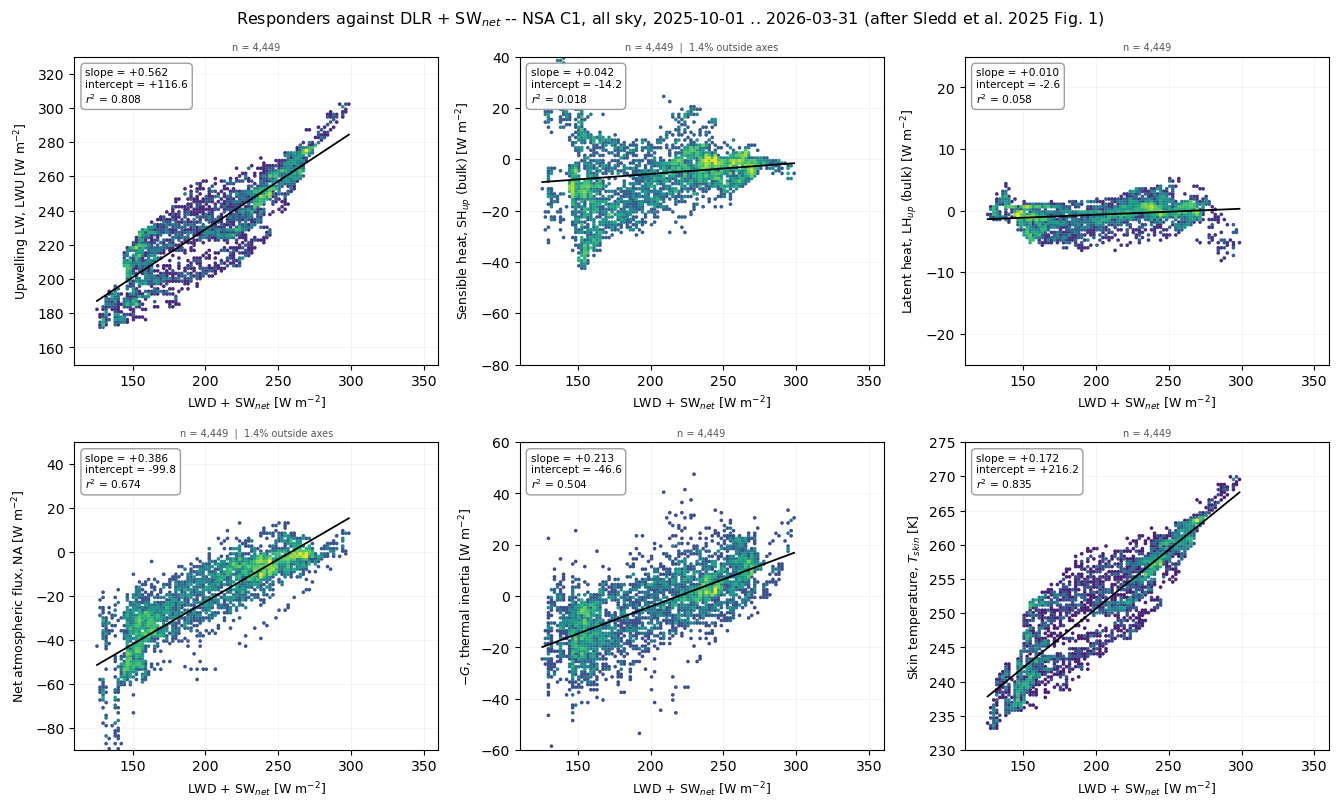

In [4]:
DEC = MASKS["all"] & fr.month_mask(OBS, [12])
fr.fig_all_responders(OBS, DEC, forcer="fnet", population="all", out_dir=SAVE_DIR, stem="december_all_responders_vs_fnet");
q = fr.partition(OBS, DEC, "fnet"); r2 = fr.partition_r2(OBS, DEC, "fnet")
print(f"{'':<12}{'Barrow Dec 2025':>18}{'r2':>7}{'MOSAiC Dec 2019':>18}")
for k, sk in (("f_lwu", "lwu"), ("f_sh", "sh"), ("f_lh", "lh"), ("f_g_ti", "g")):
    print(f"{fr.TERM_STYLE[k][0]:<28}{q[k]:>8.3f}{r2[k]:>7.2f}{fr.SLEDD_FIG1_DECEMBER[sk]:>12.2f}")
print(f"{'NA (residual)':<28}{q['f_res']:>8.3f}{r2['f_res']:>7.2f}{'--':>12}")


## 3. The four responders, and $-G_{TI}$, against $F$ by population

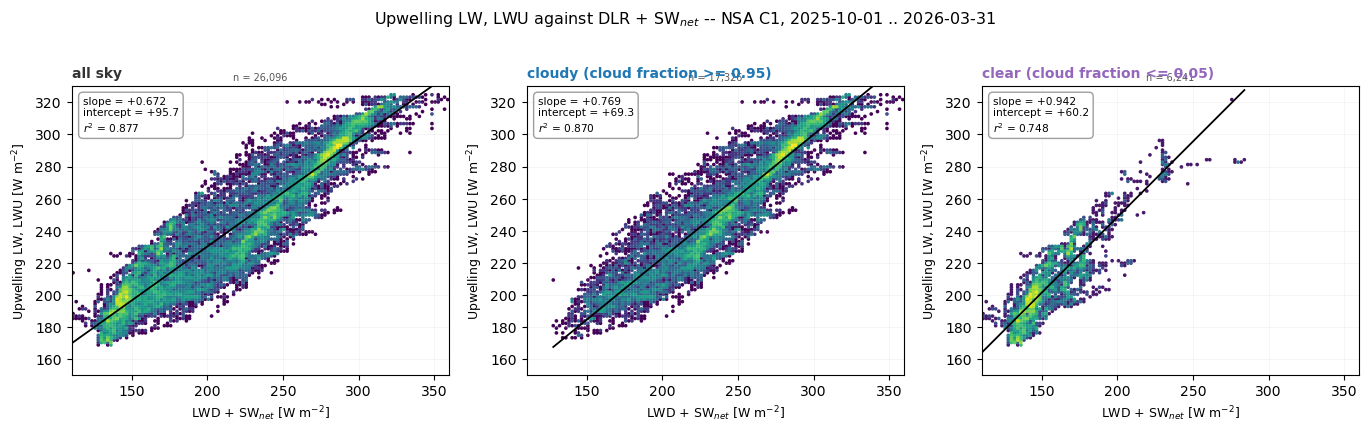

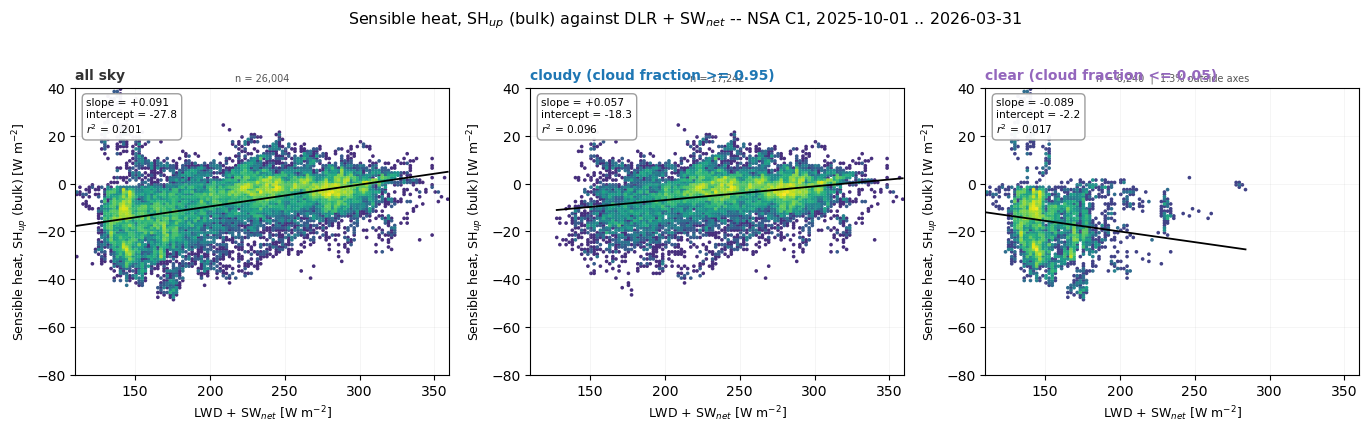

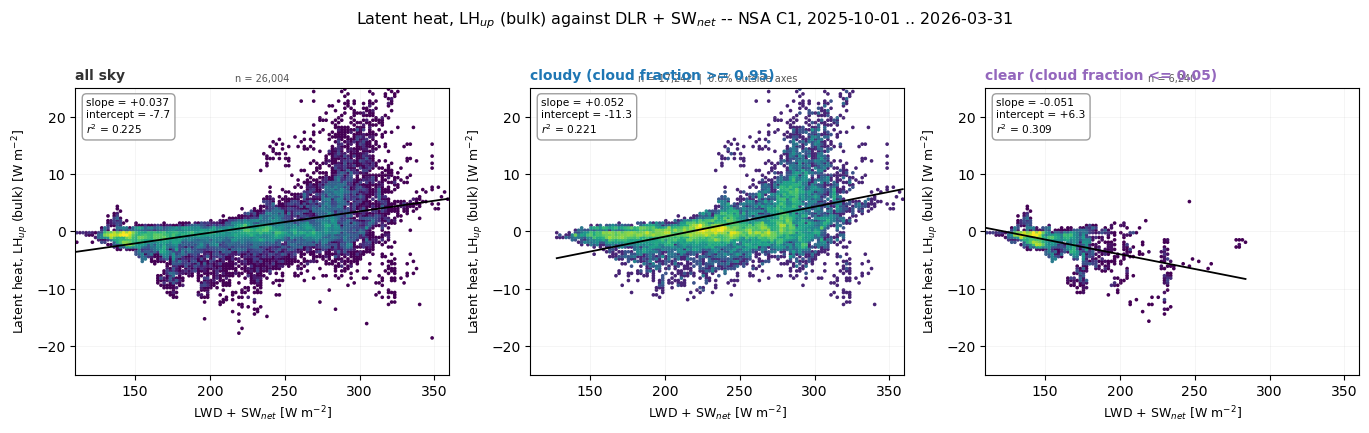

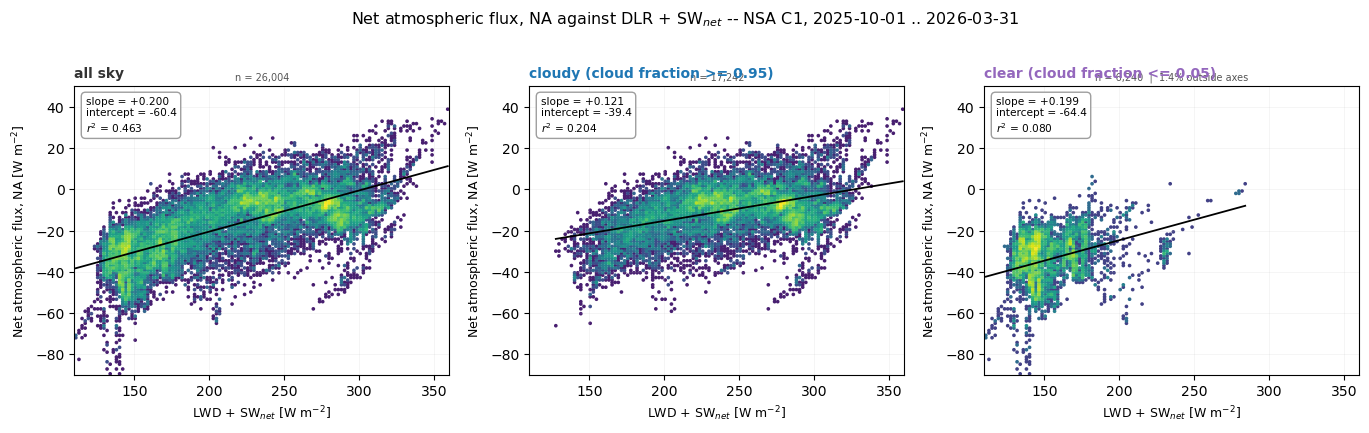

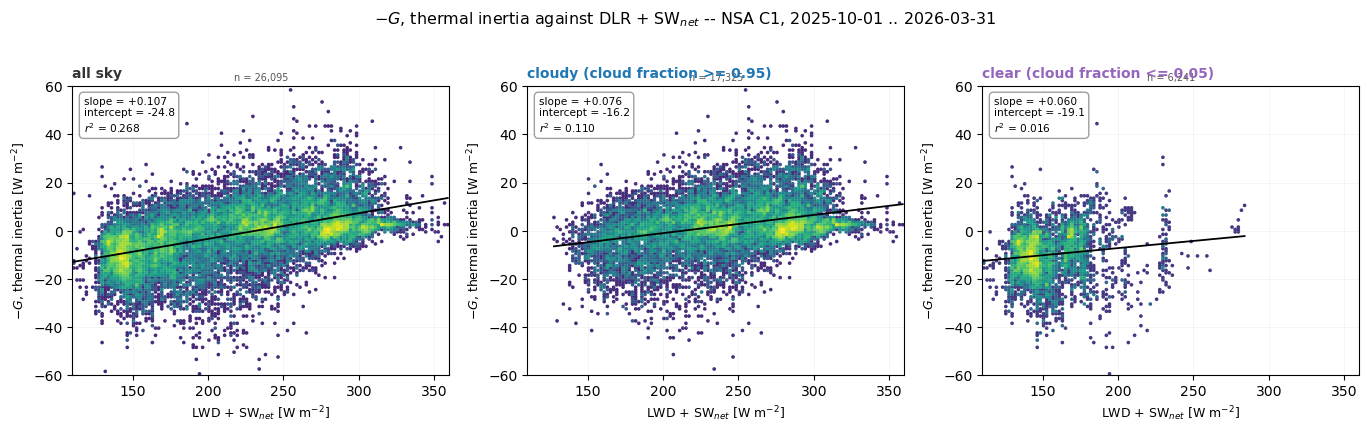

In [5]:
for y in ("lwu", "sh_up", "lh_up", "na", "neg_g_ti"):
    fr.fig_responder_vs_forcer(OBS, MASKS, y, forcer="fnet", out_dir=SAVE_DIR);


## 4. The partition on the two forcers, side by side

Left-to-right within each term: the four populations. Mean SW$_{net}$ over the
season is small (Oct and Mar carry it), so the two forcers differ mainly in
those months; in December and January they are the same numbers. Error bars:
95% moving-block bootstrap.


pop      forcer   f_LWU    f_SH    f_LH    f_SW   f_res  f_G(TI)   total   dTs/dF
all         lwd   0.694   0.091   0.037  -0.020   0.198    0.109   0.931   0.1937
all        fnet   0.672   0.091   0.037     nan   0.199    0.107   0.908   0.1877
cloudy      lwd   0.795   0.055   0.052  -0.013   0.112    0.076   0.978   0.2095
cloudy     fnet   0.769   0.057   0.052     nan   0.122    0.076   0.954   0.2027
liquid      lwd   0.907   0.009   0.061  -0.024   0.047    0.043   1.020   0.2330
liquid     fnet   0.860   0.012   0.061     nan   0.067    0.043   0.976   0.2208
clear       lwd   1.021  -0.109  -0.057  -0.023   0.169    0.048   0.903   0.3081
clear      fnet   0.942  -0.089  -0.051     nan   0.199    0.060   0.861   0.2871

pop     term       value              95% CI n_block
all     f_lwu      0.672   [+0.617, +0.705]      26
all     f_sh       0.091   [+0.062, +0.126]      26
all     f_lh       0.037   [+0.021, +0.051]      26
all     f_res      0.199   [+0.161, +0.255]      26


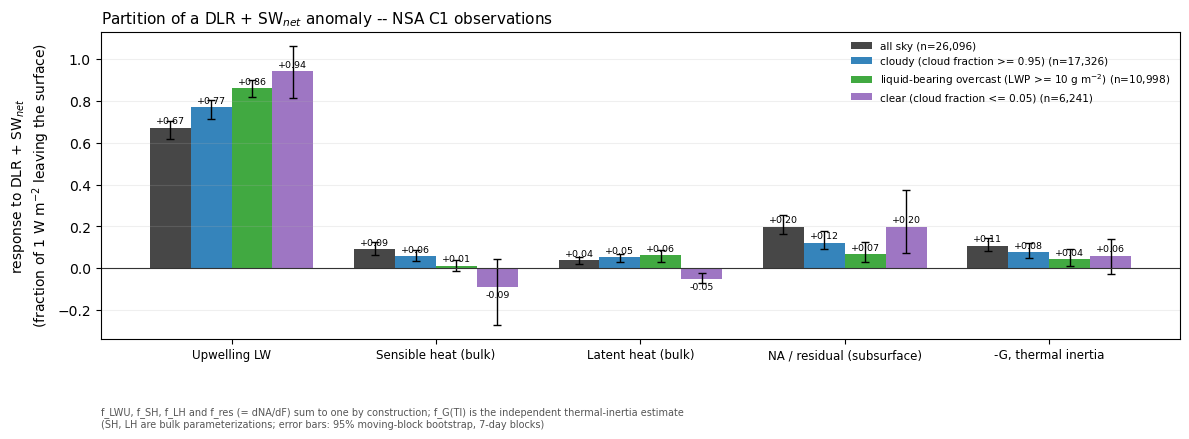

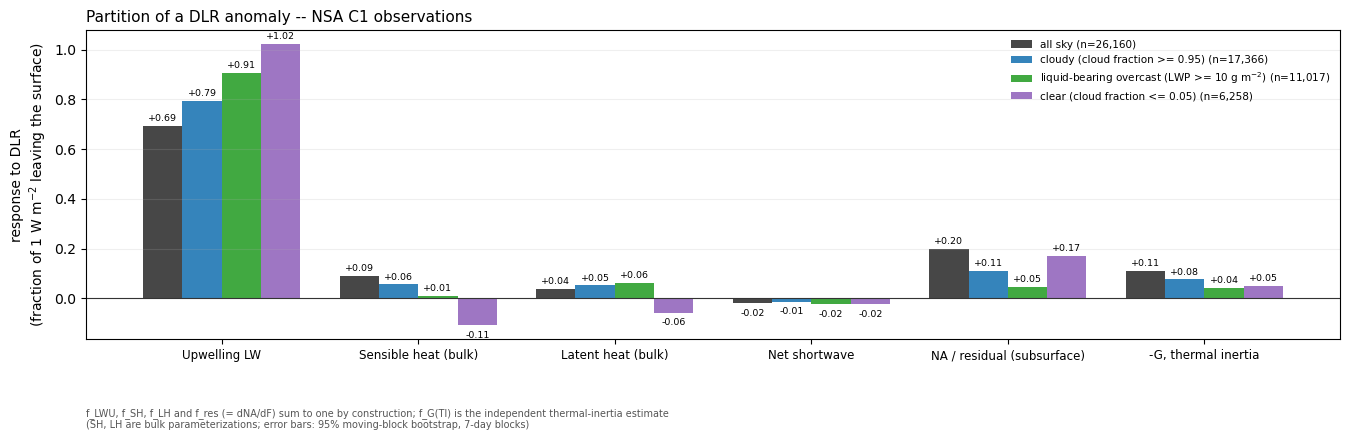

In [6]:
POPS = ("all", "cloudy", "liquid", "clear")
PARTS = {f: {p: fr.partition(OBS, MASKS[p], f) for p in POPS} for f in ("lwd", "fnet")}
CI = {p: fr.bootstrap_partition(OBS, MASKS[p], "fnet", n_boot=N_BOOT) for p in POPS}
fr.fig_partition_bars(PARTS["fnet"], "fnet", intervals=CI, out_dir=SAVE_DIR);
fr.fig_partition_bars(PARTS["lwd"], "lwd", out_dir=SAVE_DIR, stem="partition_bars_lwd_for_comparison");
print(f"{'pop':<8}{'forcer':>7}{'f_LWU':>8}{'f_SH':>8}{'f_LH':>8}{'f_SW':>8}{'f_res':>8}{'f_G(TI)':>9}{'total':>8}{'dTs/dF':>9}")
for p in POPS:
    for f in ("lwd", "fnet"):
        q = PARTS[f][p]
        print(f"{p:<8}{f:>7}{q['f_lwu']:>8.3f}{q['f_sh']:>8.3f}{q['f_lh']:>8.3f}{q.get('f_sw', float('nan')):>8.3f}{q['f_res']:>8.3f}{q['f_g_ti']:>9.3f}{q['total_measured']:>8.3f}{q['dskt_dF']:>9.4f}")
print()
print(f"{'pop':<8}{'term':<8}{'value':>8}{'95% CI':>20}{'n_block':>8}")
for p in POPS:
    for t in ("f_lwu", "f_sh", "f_lh", "f_res", "f_g_ti", "total_measured"):
        r = CI[p][t]; print(f"{p:<8}{t:<8}{r['value']:>8.3f}   [{r['lo']:+.3f}, {r['hi']:+.3f}]{r['n_block']:>8}")


## 5. Month by month, against MOSAiC and the ERA5 cell

The direct counterpart of Sledd et al. (2025) Fig. 2a for October–March.
Filled markers: this season at Barrow, sized by $r^2$; hollow markers: the
MOSAiC values digitised from their figure (±0.02); dashed: ERA5 at the nearest
grid cell. The dotted black line is the "total measured response"
$f_{LWU} + f_{SH} + f_{LH} + f_G^{TI}$, the analogue of their black diamonds
(with the caveat of the variables section: three of those four terms are
downstream of the same skin temperature here).

Two things to keep in view while reading it: MOSAiC is one winter over drifting
pack ice at 84–88 °N with a thin snow cover over 1–2 m of ice and an ocean
beneath; Barrow is one winter over snow-covered tundra on frozen ground at
71 °N. The surface types differ in thermal inertia and in what lies below, so
agreement in $f_{LWU}$ is expected (a snow surface radiates back about half of
what it receives either way) while the subsurface share need not match.


          ---- LWU ----      ---- SH ----      ---- LH ----             -- NA / -G --       -- total --
           obs   MOSAiC      obs   MOSAiC      obs   MOSAiC   NA obs  -G(TI)   NA MOS      obs   MOSAiC
  Oct    0.531    0.535    0.102    0.150    0.126    0.020    0.241   0.198    0.285    0.957    0.940
  Nov    0.503    0.530    0.226    0.125    0.089    0.005    0.181   0.114    0.335    0.933    0.940
  Dec    0.562    0.500    0.042    0.250    0.010    0.025    0.386   0.213    0.220    0.827    0.960
  Jan    0.617    0.440    0.117    0.215    0.010    0.010    0.256   0.156    0.335    0.901    0.995
  Feb    0.536    0.565    0.136    0.130    0.003   -0.010    0.325   0.195    0.310    0.870    0.945
  Mar    0.552    0.535    0.153    0.320    0.016    0.005    0.280   0.156    0.120    0.877    1.075


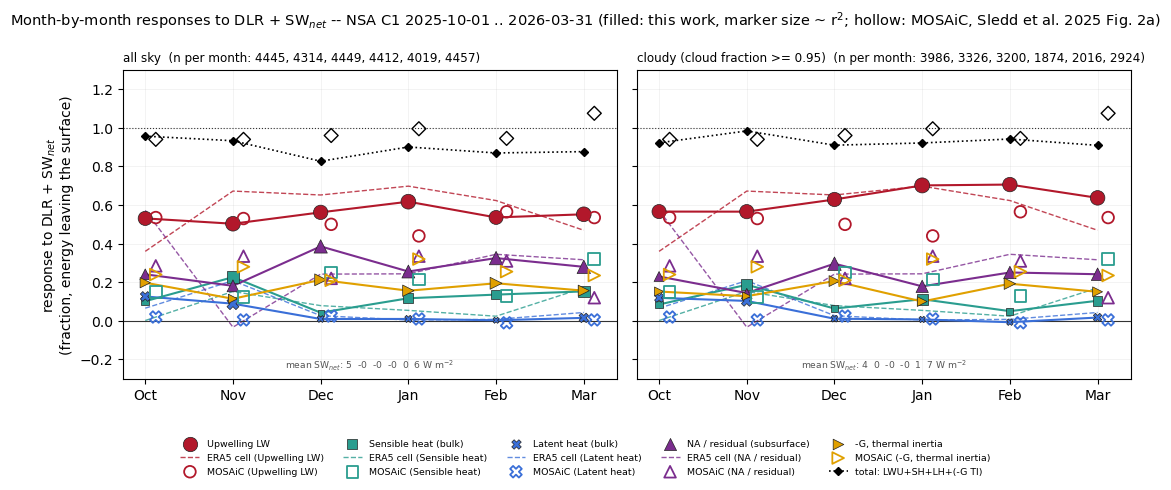

In [7]:
fr.fig_monthly_response(OBS, MASKS, forcer="fnet", populations=("all", "cloudy"), era5=ERA5, show_sledd=True, out_dir=SAVE_DIR);
r = fr.monthly_partition(OBS, MASKS["all"], "fnet")
S = fr.SLEDD_FIG2A_WINTER
print(f"{'':>5}{'---- LWU ----':>18}{'---- SH ----':>18}{'---- LH ----':>18}{'-- NA / -G --':>26}{'-- total --':>18}")
print(f"{'':>5}{'obs':>9}{'MOSAiC':>9}{'obs':>9}{'MOSAiC':>9}{'obs':>9}{'MOSAiC':>9}{'NA obs':>9}{'-G(TI)':>8}{'NA MOS':>9}{'obs':>9}{'MOSAiC':>9}")
for i, m in enumerate(r["months"]):
    print(f"{fr.WINTER_LABELS[i]:>5}{r['f_lwu'][i]:>9.3f}{S['lwu'][m]:>9.3f}{r['f_sh'][i]:>9.3f}{S['sh'][m]:>9.3f}"
          f"{r['f_lh'][i]:>9.3f}{S['lh'][m]:>9.3f}{r['f_res'][i]:>9.3f}{r['f_g_ti'][i]:>8.3f}{S['na'][m]:>9.3f}"
          f"{r['total_measured'][i]:>9.3f}{S['total'][m]:>9.3f}")


## 6. Closure

Two routes to the subsurface response: $dNA/dF$, which is what the *measured*
radiation leaves after the *parameterized* turbulence, and $d(-G_{TI})/dF$, the
thermal-inertia estimate from the skin-temperature history alone. Sledd et al.
compared their NA response with the buoy-measured $-G$ response and found them
"equal, or at least within measurement uncertainties" in winter. The gap here is
the closure error of the Barrow budget: it collects the LWU frost-bias episodes
(README), the bulk-flux parameterization error, and the thermal-inertia
assumptions (a homogeneous half-space with one thermal inertia for snow over
frozen soil), with no way from the data alone to apportion it.

The "total measured response" $f_{LWU} + f_{SH} + f_{LH} + f_G^{TI}$ is drawn
because it is what Sledd's black diamonds show, but at Barrow it is not an
independent test: see the variables section.


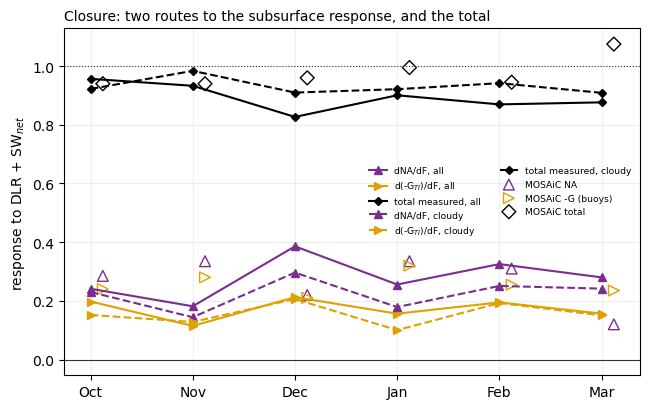

In [8]:
fig, ax = plt.subplots(figsize=(6.6, 4.2))
x = np.arange(len(fr.WINTER_MONTHS))
for p, ls in (("all", "-"), ("cloudy", "--")):
    r = fr.monthly_partition(OBS, MASKS[p], "fnet")
    ax.plot(x, r["f_res"], color=fr.TERM_STYLE["f_res"][1], ls=ls, marker="^", label=f"dNA/dF, {p}")
    ax.plot(x, r["f_g_ti"], color=fr.TERM_STYLE["f_g_ti"][1], ls=ls, marker=">", label=f"d(-G$_{{TI}}$)/dF, {p}")
    ax.plot(x, r["total_measured"], color="#000000", ls=ls, marker="D", ms=4, label=f"total measured, {p}")
ax.scatter(x + 0.12, [fr.SLEDD_FIG2A_WINTER["na"][m] for m in fr.WINTER_MONTHS], s=60, facecolor="none", edgecolor=fr.TERM_STYLE["f_res"][1], marker="^", label="MOSAiC NA")
ax.scatter(x + 0.12, [fr.SLEDD_FIG2A_WINTER["g"][m] for m in fr.WINTER_MONTHS], s=60, facecolor="none", edgecolor=fr.TERM_STYLE["f_g_ti"][1], marker=">", label="MOSAiC -G (buoys)")
ax.scatter(x + 0.12, [fr.SLEDD_FIG2A_WINTER["total"][m] for m in fr.WINTER_MONTHS], s=50, facecolor="none", edgecolor="#000000", marker="D", label="MOSAiC total")
ax.axhline(1, color="#333333", lw=0.8, ls=":"); ax.axhline(0, color="#333333", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(fr.WINTER_LABELS); ax.set_ylabel("response to DLR + SW$_{net}$"); ax.grid(alpha=0.2)
ax.legend(fontsize=6.6, frameon=False, ncol=2); ax.set_title("Closure: two routes to the subsurface response, and the total", fontsize=10, loc="left")
fig.tight_layout()
if SAVE_DIR is not None: fig.savefig(Path(SAVE_DIR) / "closure_monthly_fnet.png", dpi=fr.FIG_DPI, bbox_inches="tight")


## 7. Sledd's winter window and their Fig. 3a observational range

Sledd et al. evaluate models over 15 Oct – 14 Mar, and their Fig. 3a gives the
observed winter responses at the Central Observatory for 1-h and 3-h averages
(stars) with the range across sites as grey rectangles: LWU ≈ 0.5–0.6, NA ≈
0.2–0.3, SH ≈ 0.2, LH ≈ 0.02. The same window at Barrow, at 10-min, 1-h and
3-h averaging.


In [9]:
W = fr.sledd_winter_mask(OBS) & MASKS["all"]
W_H = fr.sledd_winter_mask(OBS_H) & MASKS_H["all"]
OBS_3H = OBS_H.resample(time="3h").mean()
OBS_3H["month"] = OBS_3H["time"].dt.month
W_3H = fr.sledd_winter_mask(OBS_3H) & np.isfinite(OBS_3H["lwd"].values)
rows = {"10-min": fr.partition(OBS, W, "fnet"), "1-h": fr.partition(OBS_H, W_H, "fnet"), "3-h": fr.partition(OBS_3H, W_3H, "fnet")}
print("15 Oct 2025 - 14 Mar 2026, all sky (Sledd et al. Fig. 3a window)")
print(f"{'avg':<8}{'f_LWU':>8}{'f_SH':>8}{'f_LH':>8}{'NA':>8}{'f_G(TI)':>9}{'total':>8}{'n':>8}")
for k, q in rows.items():
    print(f"{k:<8}{q['f_lwu']:>8.3f}{q['f_sh']:>8.3f}{q['f_lh']:>8.3f}{q['f_res']:>8.3f}{q['f_g_ti']:>9.3f}{q['total_measured']:>8.3f}{q['n']:>8}")
print("MOSAiC CO (Sledd Fig. 3a, read from the figure): LWU ~0.55-0.60, NA ~0.20-0.28, SH ~0.20, LH ~0.02")
if ERA5 is not None:
    q = fr.partition(ERA5, fr.sledd_winter_mask(ERA5) & ERA5_MASKS["all"], "fnet")
    print(f"{'ERA5 1-h':<8}{q['f_lwu']:>8.3f}{q['f_sh']:>8.3f}{q['f_lh']:>8.3f}{q['f_res']:>8.3f}{'--':>9}{'--':>8}{q['n']:>8}   (IFS in Sledd Fig. 3a: LWU ~0.40, SH ~0, NA ~0.60)")


15 Oct 2025 - 14 Mar 2026, all sky (Sledd et al. Fig. 3a window)
avg        f_LWU    f_SH    f_LH      NA  f_G(TI)   total       n
10-min     0.656   0.096   0.028   0.220    0.123   0.904   21641
1-h        0.662   0.094   0.028   0.216    0.120   0.904    3616
3-h        0.673   0.090   0.027   0.210    0.111   0.902    1208
MOSAiC CO (Sledd Fig. 3a, read from the figure): LWU ~0.55-0.60, NA ~0.20-0.28, SH ~0.20, LH ~0.02
ERA5 1-h   0.764   0.093   0.072   0.071       --      --    3624   (IFS in Sledd Fig. 3a: LWU ~0.40, SH ~0, NA ~0.60)


## 8. The control ladder and the bulk-flux free parameters

scheme          z0 [m]   f_LWU    f_SH    f_LH   f_res  mean SH
grachev2007      1e-04   0.672   0.082   0.034   0.212    -7.33
grachev2007      3e-04   0.672   0.091   0.037   0.199    -8.19
grachev2007      1e-03   0.672   0.101   0.040   0.187    -8.98
beljaars1991     1e-04   0.672   0.080   0.034   0.214    -7.25
beljaars1991     3e-04   0.672   0.090   0.037   0.201    -8.12
beljaars1991     1e-03   0.672   0.099   0.040   0.189    -8.91


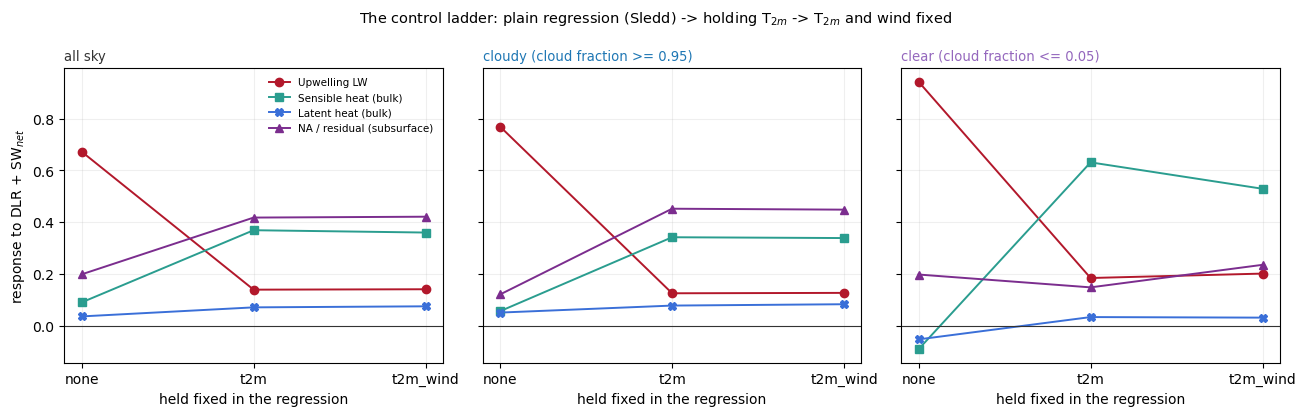

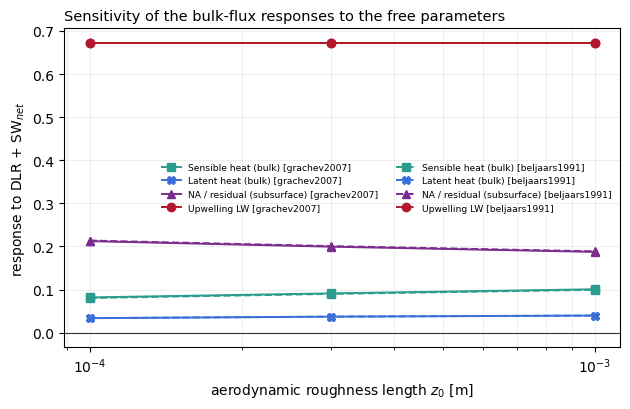

In [10]:
fr.fig_control_ladder(OBS, MASKS, forcer="fnet", out_dir=SAVE_DIR);
Z0_ROWS = fr.z0_sensitivity(OBS, MASKS["all"], forcer="fnet")
fr.fig_z0_sensitivity(Z0_ROWS, forcer="fnet", out_dir=SAVE_DIR);
print(f"{'scheme':<14}{'z0 [m]':>8}{'f_LWU':>8}{'f_SH':>8}{'f_LH':>8}{'f_res':>8}{'mean SH':>9}")
for r in Z0_ROWS:
    print(f"{r['scheme']:<14}{r['z0_m']:>8.0e}{r['f_lwu']:>8.3f}{r['f_sh']:>8.3f}{r['f_lh']:>8.3f}{r['f_res']:>8.3f}{r['sh_up_mean']:>9.2f}")


## 9. 10-min against hourly

10-min, all sky    f_lwu=+0.672  f_sh=+0.091  f_lh=+0.037  f_res=+0.199  f_g_ti=+0.107  total_measured=+0.908  | dTs/dF=0.1877 K/(W m-2)  d(Ts-T2m)/dF=+0.0187  n=26096
hourly, all sky    f_lwu=+0.679  f_sh=+0.089  f_lh=+0.037  f_res=+0.195  f_g_ti=+0.103  total_measured=+0.908  | dTs/dF=0.1895 K/(W m-2)  d(Ts-T2m)/dF=+0.0185  n=4360


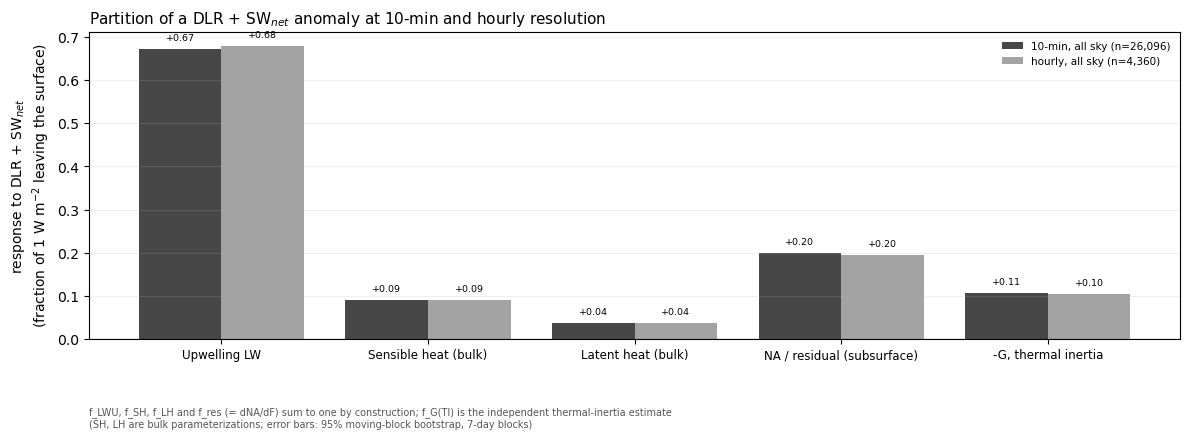

In [11]:
RES = {"10-min, all sky": fr.partition(OBS, MASKS["all"], "fnet"), "hourly, all sky": fr.partition(OBS_H, MASKS_H["all"], "fnet")}
fr.POP_LABELS.update({k: k for k in RES}); fr.POP_COLORS.update({"10-min, all sky": "#333333", "hourly, all sky": "#999999"})
fr.fig_resolution_comparison(RES, "fnet", out_dir=SAVE_DIR);
for k, v in RES.items():
    print(f"{k:<18}", fr.format_partition(v))


## What this record shows against MOSAiC

Same season and estimator as the DLR notebook, forcer $F$ = DLR + SW$_{net}$,
10-min data, 95% moving-block bootstrap intervals (26 blocks).

**All sky, Oct–Mar.** $f_{LWU}$ = 0.67 [0.62, 0.71], $f_{SH}$ = 0.09 [0.06, 0.13],
$f_{LH}$ = 0.04, $dNA/dF$ = 0.20 [0.16, 0.26], $d(-G_{TI})/dF$ = 0.11 [0.08,
0.14]; the "total measured response" $f_{LWU} + f_{SH} + f_{LH} + f_G^{TI}$ is
0.91 [0.88, 0.93]. In Sledd's winter window (15 Oct – 14 Mar): LWU 0.66, SH
0.10, LH 0.03, NA 0.22 at 10-min, and within 0.02 of that at 1-h and 3-h.
MOSAiC's Central Observatory (their Fig. 3a): LWU ≈ 0.55–0.60, SH ≈ 0.20,
LH ≈ 0.02, NA ≈ 0.20–0.28.

**Month by month (Sledd Fig. 2a).** The LWU response at Barrow is 0.50–0.62
against 0.44–0.57 at MOSAiC — the same physics (a snow surface re-radiates
about half of what it receives) at a warmer surface (−5 to −28 °C monthly
means, against −16 to −31 °C). December matches their Fig. 1 on the radiative
and subsurface terms: LWU 0.56 (theirs 0.50), $-G$ 0.21 (0.20), LH 0.01
(0.02). The subsurface responses bracket theirs: $dNA/dF$ 0.18–0.39 (MOSAiC NA
0.12–0.34), $d(-G_{TI})/dF$ 0.11–0.21 (MOSAiC buoys 0.21–0.32).

**The turbulent response is the discrepancy, and it is the parameterized
term.** Bulk $f_{SH}$ is 0.04–0.23 by month, 0.09 over the season, against
MOSAiC's eddy-covariance 0.13–0.32; in December it is 0.04 with $r^2$ = 0.02,
i.e. no relation at all, where MOSAiC found 0.25 with $r^2$ = 0.48. Neither
$z_0$ (0.08–0.10 across a decade) nor the stable-stability scheme closes the
gap. Two readings are consistent with the data and cannot be separated here:
the bulk formula with SHEBA-type strongly damped stable functions
under-responds when the surface warms under cloud, or the tundra boundary
layer genuinely couples less than the one over a 1–2 m ice floe with an ocean
beneath. The Oliktok Point ECOR (`ecor_e10`, once screened for riming) is the
only measured turbulent flux on the North Slope that could arbitrate.

**Closure.** The two routes to the subsurface response differ by 0.05–0.17 by
month, with $dNA/dF$ the larger. Because SH, LH and $G_{TI}$ are all functions
of the measured skin temperature, the total of 0.83–0.96 is a consistency
statement, not the independent closure MOSAiC's buoys allowed. A budget that
closed on measured terms would need eddy-covariance fluxes and a snow/soil
heat-flux measurement at Barrow; neither exists (README).

**ERA5 at the same cell.** LWU 0.76, SH 0.09, LH 0.07, NA 0.07 in Sledd's
window. That is nothing like the IFS over MOSAiC ice in their Fig. 3a (LWU
≈ 0.40, SH ≈ 0, NA ≈ 0.60): a land cell with a snow scheme partitions the
anomaly the way the observations do, only with more emission and less
subsurface. The no-snow-on-sea-ice failure they diagnose does not apply to a
tundra cell.
